In [3]:
import json
import numpy as np
import pandas as pd
import joblib

from collections import Counter

In [4]:
data_path = "../../data/raw/ember2018"

family_records = []

for partition in range(1, 6):
    file_path = f"{data_path}/train_features_{partition}.jsonl"

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line)

            # Only malware samples
            if str(record.get("label")) == "1":
                # Only samples with a family label
                if record.get("avclass"):
                    family_records.append(record)

print("Total malware records with family labels:", len(family_records))

Total malware records with family labels: 289246


In [5]:
family_counts = Counter(
    record["avclass"]
    for record in family_records
)

top_20_families = [
    family
    for family, count in family_counts.most_common(20)
]

print("Top 20 malware families:")
for family in top_20_families:
    print(family, family_counts[family])

Top 20 malware families:
xtrat 16689
installmonster 16356
zusy 13951
vtflooder 12118
zbot 10782
ramnit 10275
fareit 10274
sality 9522
adposhel 8570
emotet 8039
high 7706
sivis 4377
flystudio 4351
wapomi 4236
startsurf 3993
dealply 3934
upatre 3901
bladabindi 3669
razy 3223
filetour 3199


In [6]:
family_records = [
    record
    for record in family_records
    if record["avclass"] in top_20_families
]

print("Samples for Top 20 families:", len(family_records))

Samples for Top 20 families: 159165


In [7]:
feature_list = joblib.load("../../models/final_features.pkl")

print("Number of features:", len(feature_list))
print(feature_list)

Number of features: 25
['imports_count', 'strings_avlength', 'total_imported_functions', 'strings_entropy', 'hist_min', 'general_imports', 'entropy_max', 'general_vsize', 'general_has_tls', 'strings_MZ', 'entropy_std', 'strings_urls', 'hist_std', 'strings_printables', 'hist_max', 'strings_numstrings', 'general_size', 'hist_sum', 'hist_mean', 'entropy_mean', 'general_has_debug', 'section_sections_count', 'strings_paths', 'general_has_signature', 'general_exports']


In [8]:
def extract_family_features(record):
    general = record.get("general", {})
    strings = record.get("strings", {})
    imports = record.get("imports", {})
    section = record.get("section", {})

    histogram = np.asarray(
        record.get("histogram", []),
        dtype=float
    )

    byteentropy = np.asarray(
        record.get("byteentropy", []),
        dtype=float
    )

    features = {
        "imports_count": len(imports),

        "total_imported_functions": sum(
            len(functions)
            for functions in imports.values()
            if isinstance(functions, list)
        ),

        "strings_avlength": strings.get("avlength", 0),
        "strings_entropy": strings.get("entropy", 0),
        "strings_MZ": strings.get("MZ", 0),
        "strings_urls": strings.get("urls", 0),
        "strings_printables": strings.get("printables", 0),
        "strings_numstrings": strings.get("numstrings", 0),
        "strings_paths": strings.get("paths", 0),

        "hist_min": np.min(histogram) if len(histogram) else 0,
        "hist_max": np.max(histogram) if len(histogram) else 0,
        "hist_std": np.std(histogram) if len(histogram) else 0,
        "hist_sum": np.sum(histogram) if len(histogram) else 0,
        "hist_mean": np.mean(histogram) if len(histogram) else 0,

        "entropy_max": np.max(byteentropy) if len(byteentropy) else 0,
        "entropy_std": np.std(byteentropy) if len(byteentropy) else 0,
        "entropy_mean": np.mean(byteentropy) if len(byteentropy) else 0,

        "general_size": general.get("size", 0),
        "general_vsize": general.get("vsize", 0),
        "general_has_debug": general.get("has_debug", 0),
        "general_imports": general.get("imports", 0),
        "general_has_signature": general.get("has_signature", 0),
        "general_has_tls": general.get("has_tls", 0),
        "general_exports": general.get("exports", 0),

        "section_sections_count": len(
            section.get("sections", [])
        )
    }

    return features

In [9]:
family_feature_rows = []
family_labels = []

for record in family_records:
    family_feature_rows.append(
        extract_family_features(record)
    )
    family_labels.append(record["avclass"])

X_family = pd.DataFrame(family_feature_rows)
y_family = pd.Series(
    family_labels,
    name="family"
)

# Keep exactly the 25 features used by the final binary model
X_family = X_family[feature_list]

print("X_family shape:", X_family.shape)
print("y_family shape:", y_family.shape)

X_family shape: (159165, 25)
y_family shape: (159165,)


In [10]:
print("Feature matrix shape:", X_family.shape)

print("\nMissing values:")
print(X_family.isnull().sum().sum())

print("\nAll-zero features:")
print(
    X_family.columns[
        (X_family == 0).all()
    ].tolist()
)

print("\nFamily distribution:")
print(y_family.value_counts())

Feature matrix shape: (159165, 25)

Missing values:
0

All-zero features:
[]

Family distribution:
family
xtrat             16689
installmonster    16356
zusy              13951
vtflooder         12118
zbot              10782
ramnit            10275
fareit            10274
sality             9522
adposhel           8570
emotet             8039
high               7706
sivis              4377
flystudio          4351
wapomi             4236
startsurf          3993
dealply            3934
upatre             3901
bladabindi         3669
razy               3223
filetour           3199
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split

X_train_family, X_test_family, y_train_family, y_test_family = train_test_split(
    X_family,
    y_family,
    test_size=0.20,
    random_state=42,
    stratify=y_family
)

print("Training shape:", X_train_family.shape)
print("Testing shape :", X_test_family.shape)

print("\nTraining family distribution:")
print(y_train_family.value_counts())

print("\nTesting family distribution:")
print(y_test_family.value_counts())

Training shape: (127332, 25)
Testing shape : (31833, 25)

Training family distribution:
family
xtrat             13351
installmonster    13085
zusy              11161
vtflooder          9694
zbot               8626
ramnit             8220
fareit             8219
sality             7618
adposhel           6856
emotet             6431
high               6165
sivis              3502
flystudio          3481
wapomi             3389
startsurf          3194
dealply            3147
upatre             3121
bladabindi         2935
razy               2578
filetour           2559
Name: count, dtype: int64

Testing family distribution:
family
xtrat             3338
installmonster    3271
zusy              2790
vtflooder         2424
zbot              2156
ramnit            2055
fareit            2055
sality            1904
adposhel          1714
emotet            1608
high              1541
sivis              875
flystudio          870
wapomi             847
startsurf          799
dealply          

In [12]:
from sklearn.ensemble import RandomForestClassifier

family_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

family_model.fit(
    X_train_family,
    y_train_family
)

print("Family model training completed.")

Family model training completed.


In [13]:
y_pred_family = family_model.predict(X_test_family)

print("Predictions generated.")

Predictions generated.


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test_family, y_pred_family)

precision = precision_score(
    y_test_family,
    y_pred_family,
    average="weighted"
)

recall = recall_score(
    y_test_family,
    y_pred_family,
    average="weighted"
)

f1 = f1_score(
    y_test_family,
    y_pred_family,
    average="weighted"
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9425
Precision: 0.9433
Recall:    0.9425
F1 Score:  0.9427


In [15]:
macro_f1 = f1_score(
    y_test_family,
    y_pred_family,
    average="macro"
)

print(f"Macro F1: {macro_f1:.4f}")

Macro F1: 0.9305


In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_family,
        y_pred_family,
        digits=4
    )
)

                precision    recall  f1-score   support

      adposhel     0.9959    0.9895    0.9927      1714
    bladabindi     0.8027    0.8869    0.8427       734
       dealply     0.9773    0.9860    0.9817       787
        emotet     0.9869    0.9813    0.9841      1608
        fareit     0.9388    0.9625    0.9505      2055
      filetour     0.9922    0.9891    0.9906       640
     flystudio     0.9702    0.9736    0.9719       870
          high     0.7027    0.6995    0.7011      1541
installmonster     0.9948    0.9972    0.9960      3271
        ramnit     0.8754    0.9022    0.8886      2055
          razy     0.6988    0.7085    0.7036       645
        sality     0.8920    0.9023    0.8971      1904
         sivis     0.9977    1.0000    0.9989       875
     startsurf     0.9707    0.9937    0.9821       799
        upatre     0.9382    0.9538    0.9460       780
     vtflooder     0.9992    0.9983    0.9988      2424
        wapomi     0.8943    0.9091    0.9016  

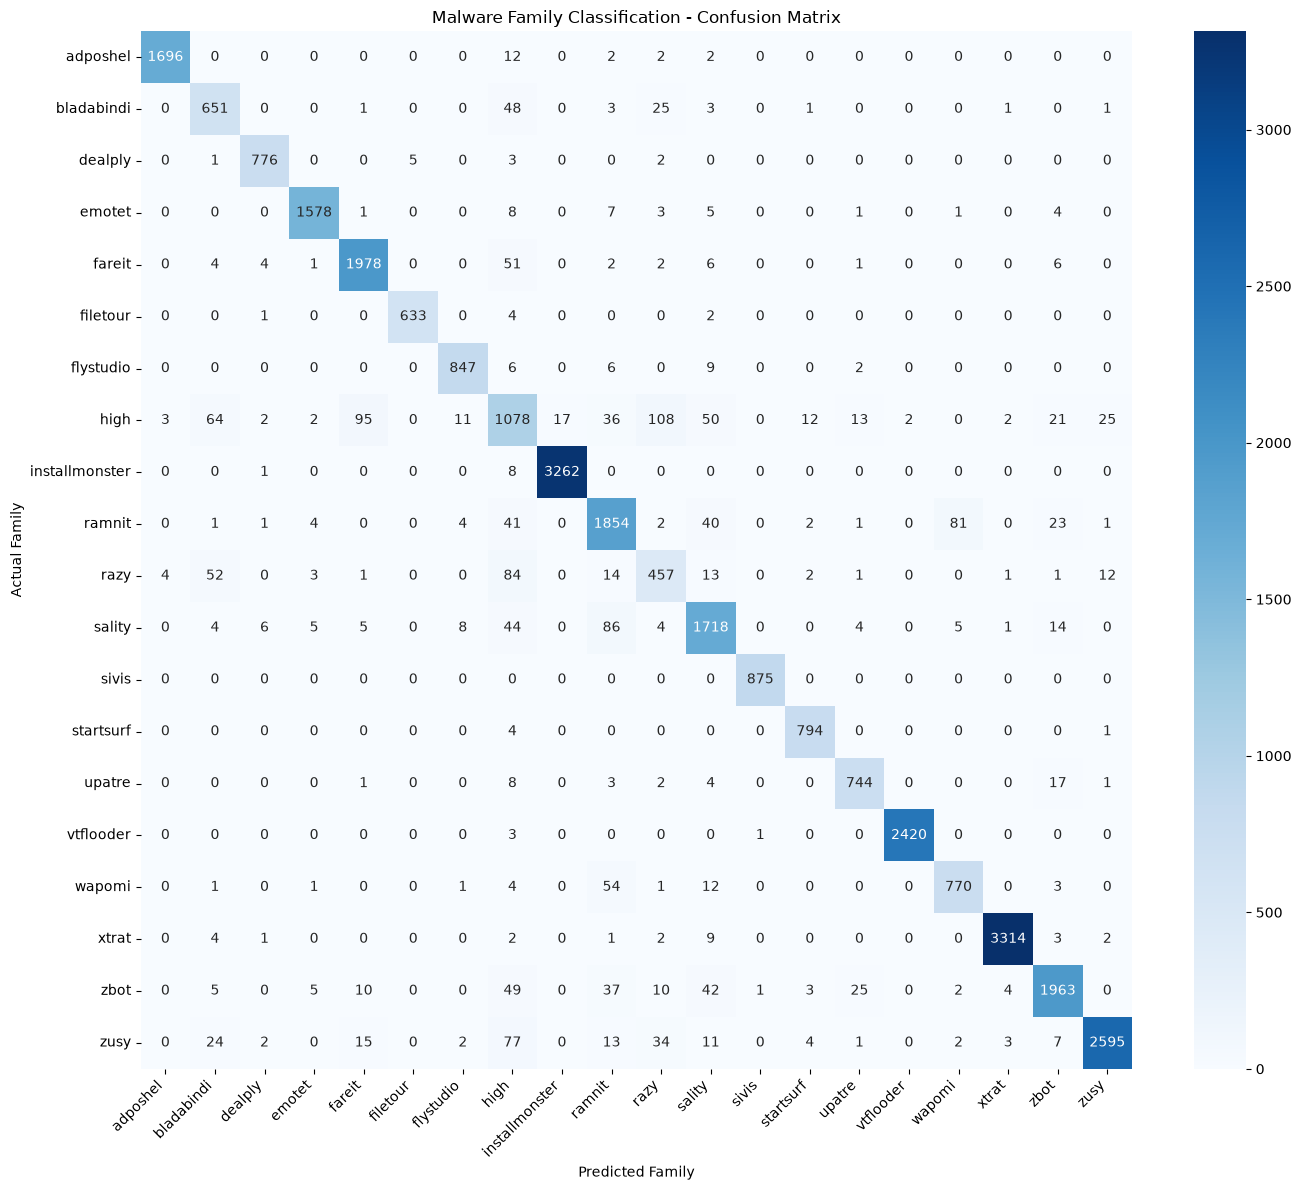

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test_family,
    y_pred_family,
    labels=family_model.classes_
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=family_model.classes_,
    yticklabels=family_model.classes_
)

plt.xlabel("Predicted Family")
plt.ylabel("Actual Family")
plt.title("Malware Family Classification - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({
    "feature": X_train_family.columns,
    "importance": family_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

                     feature  importance
2   total_imported_functions    0.083458
7              general_vsize    0.082270
5            general_imports    0.078745
1           strings_avlength    0.055208
13        strings_printables    0.054217
4                   hist_min    0.048193
12                  hist_std    0.046685
0              imports_count    0.046209
14                  hist_max    0.046066
21    section_sections_count    0.041993
10               entropy_std    0.040854
11              strings_urls    0.040344
3            strings_entropy    0.037930
18                 hist_mean    0.037031
6                entropy_max    0.036164
16              general_size    0.035335
15        strings_numstrings    0.034721
17                  hist_sum    0.033580
19              entropy_mean    0.028430
8            general_has_tls    0.024075
20         general_has_debug    0.018038
24           general_exports    0.016023
22             strings_paths    0.012174
9               

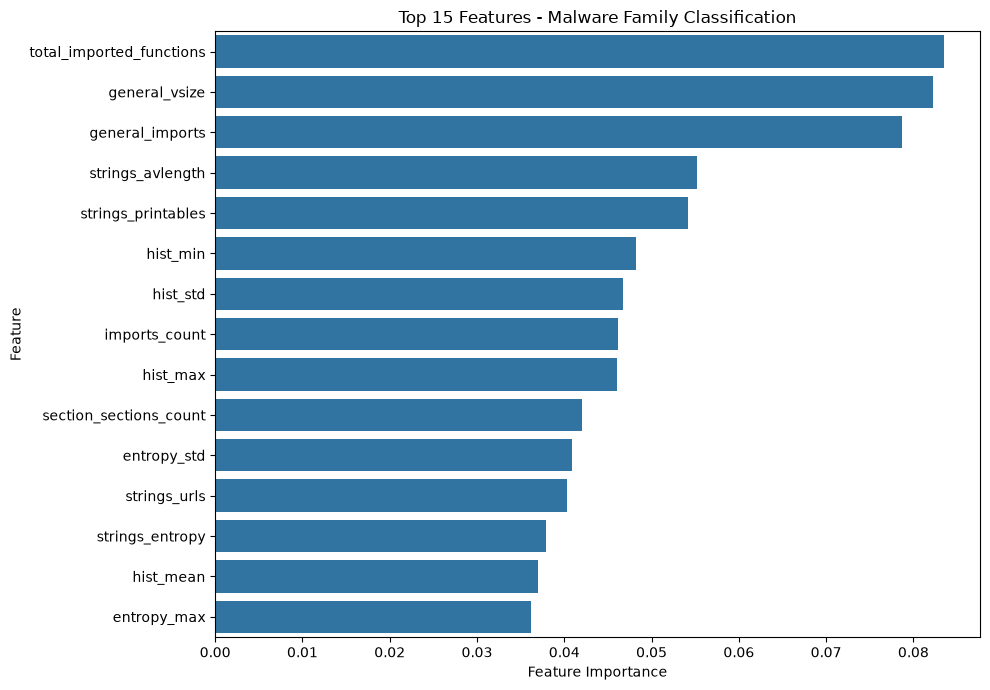

In [19]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top 15 Features - Malware Family Classification")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [20]:
import joblib

FAMILY_MODEL_PATH = "../../models/malware_family_rf.pkl"

joblib.dump(
    family_model,
    FAMILY_MODEL_PATH
)

print("Family model saved successfully.")
print("Path:", FAMILY_MODEL_PATH)

Family model saved successfully.
Path: ../../models/malware_family_rf.pkl


In [21]:
family_model.classes_

array(['adposhel', 'bladabindi', 'dealply', 'emotet', 'fareit',
       'filetour', 'flystudio', 'high', 'installmonster', 'ramnit',
       'razy', 'sality', 'sivis', 'startsurf', 'upatre', 'vtflooder',
       'wapomi', 'xtrat', 'zbot', 'zusy'], dtype=object)

In [22]:
FAMILY_LABELS_PATH = "../../models/family_labels.pkl"

joblib.dump(
    family_model.classes_,
    FAMILY_LABELS_PATH
)

print("Family labels saved successfully.")
print("Path:", FAMILY_LABELS_PATH)
print("Number of families:", len(family_model.classes_))
print("Families:", list(family_model.classes_))

Family labels saved successfully.
Path: ../../models/family_labels.pkl
Number of families: 20
Families: ['adposhel', 'bladabindi', 'dealply', 'emotet', 'fareit', 'filetour', 'flystudio', 'high', 'installmonster', 'ramnit', 'razy', 'sality', 'sivis', 'startsurf', 'upatre', 'vtflooder', 'wapomi', 'xtrat', 'zbot', 'zusy']


In [23]:
loaded_family_model = joblib.load(
    FAMILY_MODEL_PATH
)

loaded_family_labels = joblib.load(
    FAMILY_LABELS_PATH
)

print("Model loaded:", type(loaded_family_model).__name__)
print("Number of features:", loaded_family_model.n_features_in_)
print("Number of classes:", len(loaded_family_model.classes_))
print("Labels loaded:", list(loaded_family_labels))

Model loaded: RandomForestClassifier
Number of features: 25
Number of classes: 20
Labels loaded: ['adposhel', 'bladabindi', 'dealply', 'emotet', 'fareit', 'filetour', 'flystudio', 'high', 'installmonster', 'ramnit', 'razy', 'sality', 'sivis', 'startsurf', 'upatre', 'vtflooder', 'wapomi', 'xtrat', 'zbot', 'zusy']


In [24]:
sample = X_test_family.iloc[[0]]

prediction = loaded_family_model.predict(sample)[0]

probabilities = loaded_family_model.predict_proba(sample)[0]

prediction_index = list(loaded_family_model.classes_).index(prediction)

prediction_probability = probabilities[prediction_index]

print("Predicted family:", prediction)
print("Family probability:", round(float(prediction_probability), 4))

Predicted family: vtflooder
Family probability: 1.0


In [25]:
import os

print("Family model exists:",
      os.path.exists("../../models/malware_family_rf.pkl"))

print("Family labels exist:",
      os.path.exists("../../models/family_labels.pkl"))

Family model exists: True
Family labels exist: True


In [26]:
import sys
sys.path.append("../..")

import inference

sample_features = X_test_family.iloc[0].to_dict()

result = inference.predict_from_features(sample_features)

print(result)

{'prediction': 'Benign', 'malware_probability': 0.42, 'risk_level': 'Medium', 'malware_family': None, 'family_probability': None}


In [27]:
for i in range(10):
    sample_features = X_test_family.iloc[i].to_dict()

    result = inference.predict_from_features(sample_features)

    print(
        f"Sample {i+1}:",
        result
    )

Sample 1: {'prediction': 'Benign', 'malware_probability': 0.42, 'risk_level': 'Medium', 'malware_family': None, 'family_probability': None}
Sample 2: {'prediction': 'Malware', 'malware_probability': 1.0, 'risk_level': 'High', 'malware_family': 'zusy', 'family_probability': 1.0}
Sample 3: {'prediction': 'Malware', 'malware_probability': 0.86, 'risk_level': 'High', 'malware_family': 'high', 'family_probability': 0.81}
Sample 4: {'prediction': 'Malware', 'malware_probability': 0.672, 'risk_level': 'Medium', 'malware_family': 'startsurf', 'family_probability': 0.995}
Sample 5: {'prediction': 'Malware', 'malware_probability': 0.896, 'risk_level': 'High', 'malware_family': 'xtrat', 'family_probability': 1.0}
Sample 6: {'prediction': 'Malware', 'malware_probability': 0.764, 'risk_level': 'High', 'malware_family': 'ramnit', 'family_probability': 1.0}
Sample 7: {'prediction': 'Malware', 'malware_probability': 1.0, 'risk_level': 'High', 'malware_family': 'installmonster', 'family_probability': 1

In [9]:
import sys
from pathlib import Path

project_root = str(Path.cwd().parents[1])

if project_root not in sys.path:
    sys.path.append(project_root)

print(project_root)

C:\Users\DELL\Desktop\Springboard\Malware-Classification-System\ml-engine


In [10]:
import importlib
import feature_extractor

importlib.reload(feature_extractor)

<module 'feature_extractor' from 'C:\\Users\\DELL\\Desktop\\Springboard\\Malware-Classification-System\\ml-engine\\feature_extractor.py'>

In [11]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parents[1]))

In [12]:
from feature_extractor import calculate_file_hashes

In [13]:
from feature_extractor import calculate_file_hashes

file_path = r"C:\Windows\System32\notepad.exe"

hashes = calculate_file_hashes(file_path)

print("MD5:", hashes["md5"])
print("SHA-256:", hashes["sha256"])

MD5: 6f51bcabf1b2b34ad7e670aee6da451f
SHA-256: da5807bb0997cc6b5132950ec87eda2b33b1ac4533cf1f7a22a6f3b576ed7c5b


In [17]:
file_path = r"C:\Windows\System32\notepad.exe"

file_type = feature_extractor.identify_file_type(file_path)

print("File type:", file_type)

File type: Windows PE


In [15]:
print(feature_extractor.__file__)

C:\Users\DELL\Desktop\Springboard\Malware-Classification-System\ml-engine\feature_extractor.py


In [16]:
print(hasattr(feature_extractor, "identify_file_type"))

True
